# Pre-Processing

### Install libraries & Load the dataset

In [2]:
import pandas as pd
import numpy as np
import os
import glob
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset:
The depresjon dataset is a collection of motor activity data token from wrist actigraphy recorded from indivisuals, some are patients ( condition group ) diagnosed with bipolar, unipolar & depression, and some are healthy ( control group ).

The dataset contains 55 files:

23 Condition ( Patients )

32 Control ( Normal )

Scores file containing metadata & clinical / demographic data

In [3]:
SCORES = pd.read_csv("/content/drive/MyDrive/Main_Datasets/Depresjon/scores.csv")
CONDITION = glob.glob("/content/drive/MyDrive/Main_Datasets/Depresjon/condition/*.csv")
CONTROL = glob.glob("/content/drive/MyDrive/Main_Datasets/Depresjon/control/*.csv")

In [4]:
SCORES.head()

,number,days,gender,age,afftype,melanch,inpatient,edu,marriage,work,madrs1,madrs2
0,condition_1,11,2,35-39,2.0,2.0,2.0,6-10,1.0,2.0,19.0,19.0
1,condition_2,18,2,40-44,1.0,2.0,2.0,6-10,2.0,2.0,24.0,11.0
2,condition_3,13,1,45-49,2.0,2.0,2.0,6-10,2.0,2.0,24.0,25.0
3,condition_4,13,2,25-29,2.0,2.0,2.0,11-15,1.0,1.0,20.0,16.0
4,condition_5,13,2,50-54,2.0,2.0,2.0,11-15,2.0,2.0,26.0,26.0


In [5]:
def load_activity():
    frames = []
    for f in CONDITION:
        df = pd.read_csv(f)
        df['number'] = os.path.basename(f).replace(".csv","")
        df['group'] = "condition"
        frames.append(df)

    for f in CONTROL:
        df = pd.read_csv(f)
        df['number'] = os.path.basename(f).replace(".csv","")
        df['group'] = "control"
        frames.append(df)

    return pd.concat(frames, ignore_index=True)

activity = load_activity()
scores = SCORES

activity.head()

,timestamp,date,activity,number,group
0,2005-03-08 10:00:00,2005-03-08,0,condition_12,condition
1,2005-03-08 10:01:00,2005-03-08,0,condition_12,condition
2,2005-03-08 10:02:00,2005-03-08,0,condition_12,condition
3,2005-03-08 10:03:00,2005-03-08,3,condition_12,condition
4,2005-03-08 10:04:00,2005-03-08,0,condition_12,condition


## Date Formating

In [6]:
# Check out the formating of the dates: strict to the same date formats
activity['datetime'] = pd.to_datetime(
    activity['timestamp'],
    format="%Y-%m-%d %H:%M:%S",
    errors='coerce'
)
activity.head()

# Remove Timestamp & Date columns
activity = activity.drop(columns=['timestamp', 'date'])

## Feature Extraction

In [7]:
def extract_super_features(df):
    # Extract hour from datetime column
    df['hour'] = df['datetime'].dt.hour

    feat = df.groupby(['number', 'group'])['activity'].agg([
        ('mean_act', 'mean'), ('std_act', 'std'), ('max_act', 'max'),
        ('zero_ratio', lambda x: (x == 0).mean()),
        ('cv_act', lambda x: np.std(x) / (np.mean(x) + 1))
    ]).reset_index()

    morning = df[(df['hour'] >= 6) & (df['hour'] <= 10)].groupby('number')['activity'].mean().reset_index(name='morning_act')
    late_night = df[(df['hour'] >= 23) | (df['hour'] <= 4)].groupby('number')['activity'].mean().reset_index(name='night_act')
    day_zero = df[(df['hour'] > 8) & (df['hour'] < 20)].groupby('number')['activity'].apply(lambda x: (x==0).mean()).reset_index(name='day_inactivity')

    # Merge all features
    final_feat = feat.merge(morning, on='number').merge(late_night, on='number').merge(day_zero, on='number')
    return final_feat.merge(SCORES, on='number', how='left')

features = extract_super_features(activity)
features['label'] = (features['group'] == 'condition').astype(int)
labeled = features.dropna(subset=['label'])

## EDA

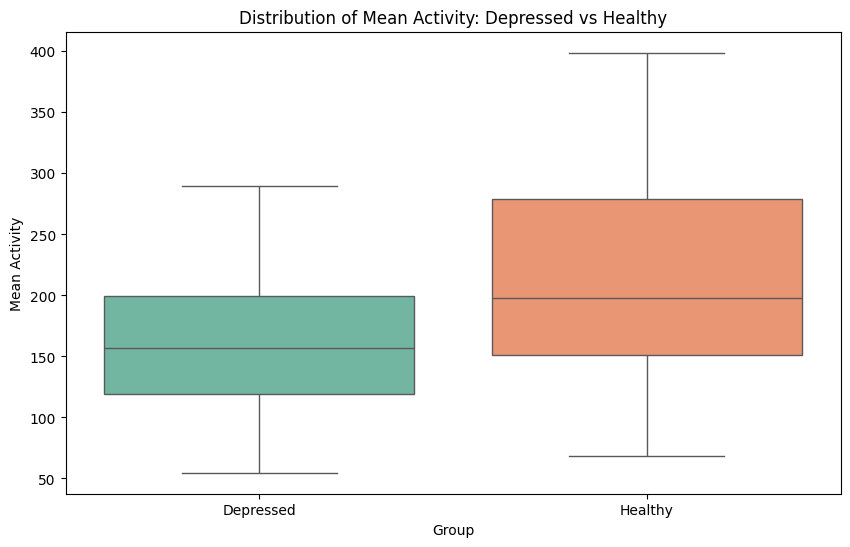

In [8]:
feat_cols = ["mean_act", "std_act", "zero_ratio", "cv_act", "morning_act", "night_act", "day_inactivity"]

output_dir = './plots'
os.makedirs(output_dir, exist_ok=True)

labeled['display_label'] = labeled['label'].map({0: 'Healthy', 1: 'Depressed'})
plt.figure(figsize=(10, 6))
sns.boxplot(x='display_label', y='mean_act', data=labeled, hue='display_label', palette='Set2', legend=False)
plt.title('Distribution of Mean Activity: Depressed vs Healthy')
plt.xlabel('Group')
plt.ylabel('Mean Activity')
plt.savefig(os.path.join(output_dir, 'mean_activity_dist.png'))
plt.show()
plt.close()

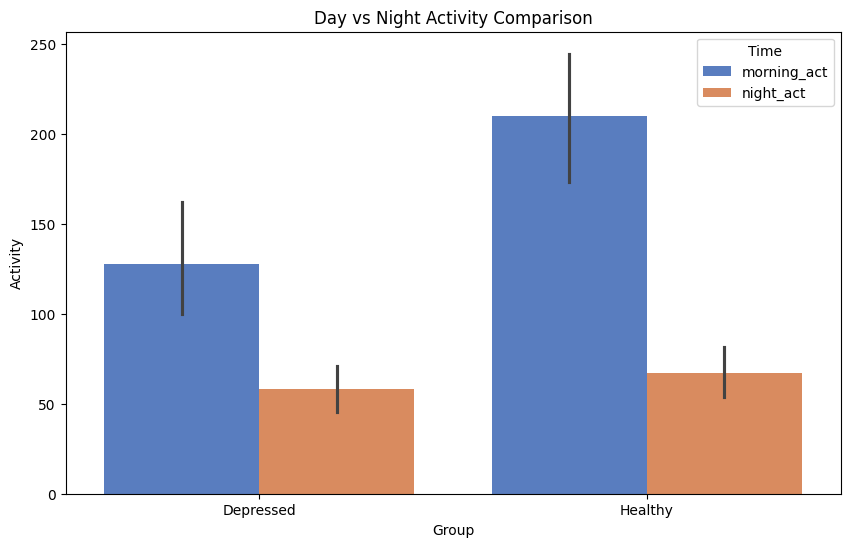

In [9]:
# Day vs Night Activity
plt.figure(figsize=(10, 6))
df_melted = labeled.melt(id_vars=['display_label'], value_vars=['morning_act', 'night_act'],
                        var_name='Time', value_name='Activity')
sns.barplot(x='display_label', y='Activity', hue='Time', data=df_melted, palette='muted')
plt.title('Day vs Night Activity Comparison')
plt.xlabel('Group')
plt.savefig(os.path.join(output_dir, 'day_night_comparison.png'))
plt.show()
plt.close()

# Models

In [10]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

## Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, recall_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

feat_cols = ["mean_act", "std_act", "zero_ratio", "cv_act", "morning_act", "night_act", "day_inactivity"]
X = labeled[feat_cols].fillna(0).values
y = labeled['label'].values
groups = labeled['number'].values
logo = LeaveOneGroupOut()

models = {
    "LogisticRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            class_weight='balanced',
            C=0.1,
            random_state=42,
            max_iter=1000
        ))
    ])
}

results = {}
for name, model_pipeline in models.items():
    all_preds, all_probs, all_true = [], [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        model_pipeline.fit(X[train_idx], y[train_idx])
        all_preds.extend(model_pipeline.predict(X[test_idx]))
        all_probs.extend(model_pipeline.predict_proba(X[test_idx])[:, 1])
        all_true.extend(y[test_idx])

    results[name] = {
        'accuracy': accuracy_score(all_true, all_preds),
        'f1': f1_score(all_true, all_preds),
        'roc_auc': roc_auc_score(all_true, all_probs),
        'recall_class1': recall_score(all_true, all_preds)
    }

# Display result
results_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
print(results_df)

                    accuracy        f1   roc_auc  recall_class1
LogisticRegression  0.636364  0.615385  0.699728       0.695652


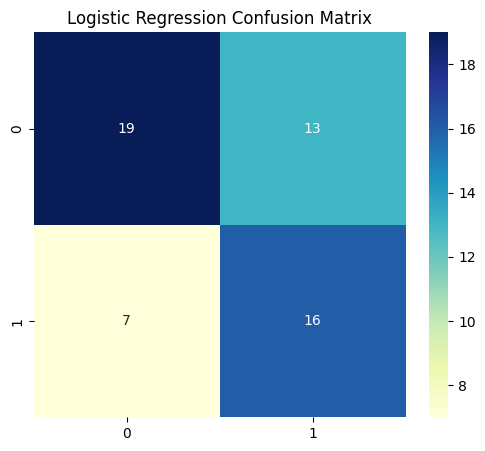

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(all_true, all_preds), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

## Random Forest

In [13]:
feat_cols = ["mean_act", "std_act", "zero_ratio", "cv_act", "morning_act", "night_act", "day_inactivity"]
X = labeled[feat_cols].fillna(0).values
y = labeled['label'].values
groups = labeled['number'].values

logo = LeaveOneGroupOut()
all_preds, all_probs, all_true = [], [], []

for train_idx, test_idx in logo.split(X, y, groups):
    clf = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_leaf=1, class_weight='balanced', random_state=42)
    clf.fit(X[train_idx], y[train_idx])
    all_preds.extend(clf.predict(X[test_idx]))
    all_probs.extend(clf.predict_proba(X[test_idx])[:, 1])
    all_true.extend(y[test_idx])

print(f"{accuracy_score(all_true, all_preds):.2%}")
print(classification_report(all_true, all_preds))

67.27%
              precision    recall  f1-score   support

           0       0.69      0.78      0.74        32
           1       0.63      0.52      0.57        23

    accuracy                           0.67        55
   macro avg       0.66      0.65      0.65        55
weighted avg       0.67      0.67      0.67        55



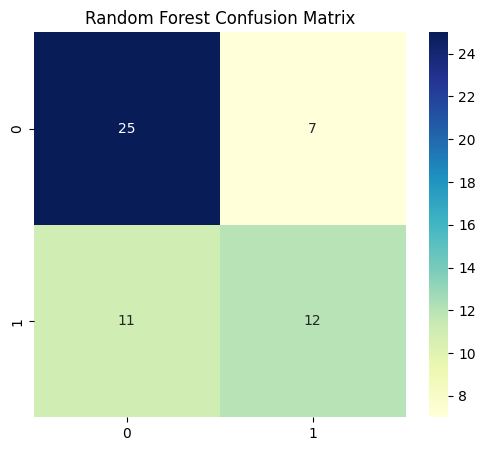

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(all_true, all_preds), annot=True, fmt='d', cmap='YlGnBu')
plt.title('Random Forest Confusion Matrix')
plt.show()